In [15]:
import sys
sys.path.append('..')

import pandas as pd
from datasets.loader import load_files, load_npy_file, load_json_file
from evaluation.visualization import plot_histories
import matplotlib.pyplot as plt
from datasets.paths import ProjectPaths
import math


In [16]:
pd.set_option("display.max_columns", None)


In [17]:
paths = ProjectPaths()


In [18]:
histories = load_files(paths.models_dir, "history.npy", load_npy_file)
print(histories.keys())


dict_keys(['bilstm_mean_cosine_noaug', 'bilstm_mean_cosine_noaug_uncased', 'bilstm_mean_mlp_noaug', 'lstm_mean_cosine_noaug', 'lstm_mean_cosine_noaug_uncased', 'lstm_mean_manhattan_noaug', 'lstm_mean_manhattan_noaug_uncased', 'lstm_mean_manhattan_noaug_uncased_32', 'lstm_mean_mlp_noaug'])


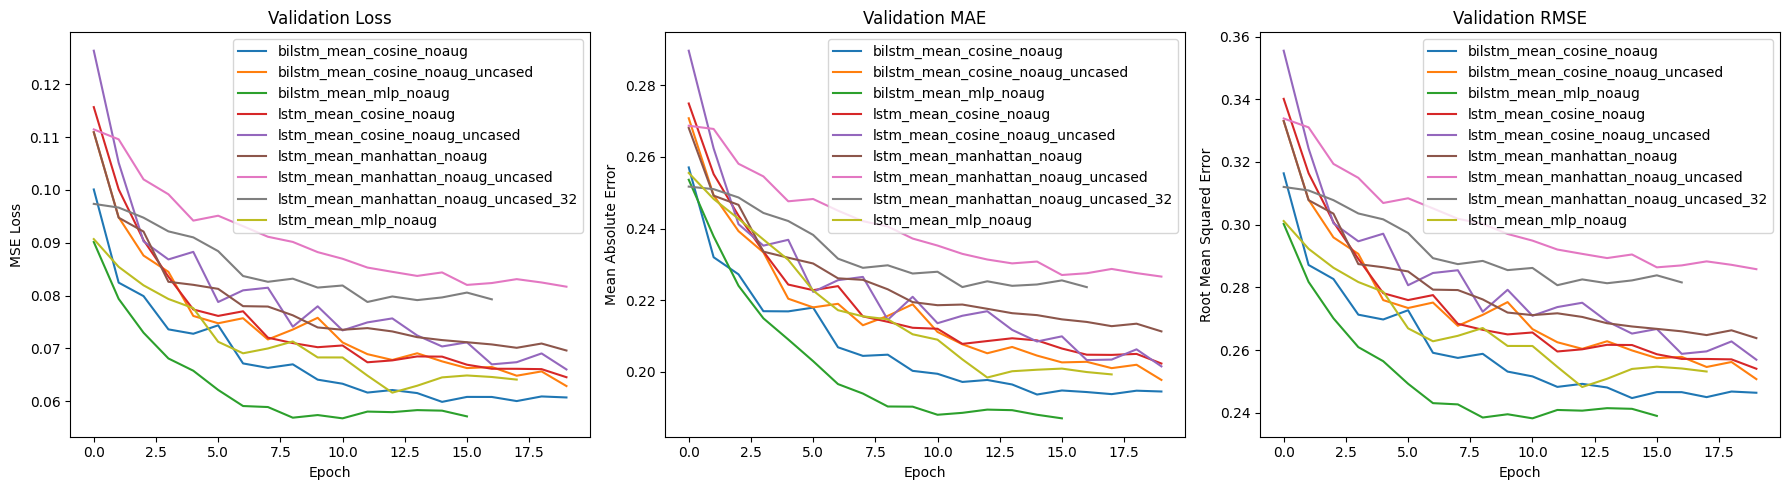

In [19]:
plot_histories(histories, paths.models_dir)


In [20]:
metrics = load_files(paths.models_dir, "metrics.json", load_json_file)
print(len(metrics))


9


In [21]:
df = pd.DataFrame(metrics.values())
display(df)


,name,hidden_dim,embedding_dim,pooling,similarity,bidirectional,mlp_layers,concat_features,mlp_dropout,lstm_dropout,sequence_length,data_augmentation,train_time_s,train_loss,train_mae,val_loss,val_mae,test_pearson,test_spearman,test_mse,test_mae,test_rmse,test_bias,test_r2,calibration_pearson,calibration_spearman,calibration_mse,calibration_mae,calibration_rmse,calibration_bias,calibration_r2
0,bilstm_mean_cosine_noaug,64,400,mean,cosine,True,[16],[diff],0.4,0.3,26,False,1857.709558,0.015710,0.100260,0.059872,0.193681,0.691568,0.679152,0.060893,0.192175,0.246764,-0.109022,0.344875,0.694421,0.677150,0.048359,0.172752,0.219907,0.013180,0.479719
1,bilstm_mean_cosine_noaug_uncased,64,400,mean,cosine,True,[32],[diff],0.4,0.3,26,False,2086.484052,0.016167,0.102019,0.062865,0.197756,0.680362,0.670979,0.061153,0.192147,0.247291,-0.102048,0.342072,0.682794,0.669728,0.050478,0.175975,0.224673,0.025692,0.456923
2,bilstm_mean_mlp_noaug,64,400,mean,mlp,True,[32],[diff],0.4,0.3,26,False,1671.580547,0.030631,0.138614,0.056751,0.188032,0.623200,0.604026,0.056944,0.189552,0.238629,0.004300,0.387358,0.626343,0.605284,0.057793,0.191071,0.240401,0.035832,0.378226
3,lstm_mean_cosine_noaug,64,400,mean,cosine,False,[16],[diff],0.4,0.3,26,False,1047.289317,0.021803,0.118323,0.064537,0.202341,0.636745,0.628953,0.072197,0.206806,0.268696,-0.119052,0.223249,0.640144,0.627894,0.055614,0.183348,0.235827,0.007459,0.401661
4,lstm_mean_cosine_noaug_uncased,64,400,mean,cosine,False,[32],[diff],0.4,0.3,26,False,1025.178893,0.022221,0.119567,0.066011,0.201543,0.648201,0.632440,0.068058,0.203766,0.260880,-0.112417,0.267779,0.649973,0.633262,0.054349,0.184832,0.233128,0.018222,0.415277
5,lstm_mean_manhattan_noaug,64,400,mean,manhattan,False,[16],[diff],0.4,0.3,26,False,959.654680,0.044614,0.174118,0.069597,0.211310,0.565359,0.553311,0.068852,0.205891,0.262396,-0.072612,0.259247,0.561288,0.552888,0.065001,0.202380,0.254953,0.028099,0.300674
6,lstm_mean_manhattan_noaug_uncased,64,400,mean,manhattan,False,[32],[diff],0.4,0.3,26,False,972.115449,0.044315,0.174109,0.081683,0.226613,0.577505,0.555199,0.074422,0.216535,0.272804,-0.111446,0.199315,0.571294,0.558207,0.064205,0.203946,0.253387,0.035968,0.309235
7,lstm_mean_manhattan_noaug_uncased_32,64,400,mean,manhattan,False,[32],[diff],0.4,0.3,26,False,1735.668640,0.043496,0.173413,0.078789,0.223684,0.560996,0.540593,0.074108,0.216103,0.272227,-0.101625,0.202697,0.553018,0.538952,0.066391,0.205907,0.257664,0.035521,0.285720
8,lstm_mean_mlp_noaug,64,400,mean,mlp,False,[16],[diff],0.4,0.3,26,False,3300.284062,0.037939,0.155672,0.061614,0.198430,0.579978,0.550129,0.061870,0.199168,0.248737,-0.005099,0.334359,0.573219,0.549685,0.064107,0.204216,0.253193,0.039482,0.310296


In [22]:
df["combined"] = df[["test_pearson", "test_spearman"]].mean(axis=1)

df = df.sort_values("combined", ascending=False)

display(df[["name", "test_pearson", "test_spearman", "combined"]])


,name,test_pearson,test_spearman,combined
0,bilstm_mean_cosine_noaug,0.691568,0.679152,0.685360
1,bilstm_mean_cosine_noaug_uncased,0.680362,0.670979,0.675671
4,lstm_mean_cosine_noaug_uncased,0.648201,0.632440,0.640320
3,lstm_mean_cosine_noaug,0.636745,0.628953,0.632849
2,bilstm_mean_mlp_noaug,0.623200,0.604026,0.613613
6,lstm_mean_manhattan_noaug_uncased,0.577505,0.555199,0.566352
8,lstm_mean_mlp_noaug,0.579978,0.550129,0.565054
5,lstm_mean_manhattan_noaug,0.565359,0.553311,0.559335
7,lstm_mean_manhattan_noaug_uncased_32,0.560996,0.540593,0.550794


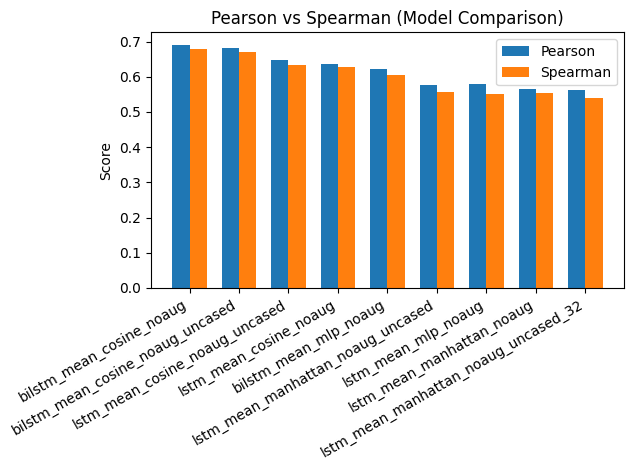

In [23]:
x = range(len(df))
width = 0.35

plt.figure()
plt.bar([i - width/2 for i in x], df["test_pearson"], width=width, label="Pearson")
plt.bar([i + width/2 for i in x], df["test_spearman"], width=width, label="Spearman")

plt.xticks(x, df["name"], rotation=30, ha="right")
plt.ylabel("Score")
plt.title("Pearson vs Spearman (Model Comparison)")
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
# Asigna una clasificación a cada modelo. Una puntuación más alta equivale a una mejor clasificación.
df["pearson_rank"] = df["test_pearson"].rank(ascending=False)
df["spearman_rank"] = df["test_spearman"].rank(ascending=False)

print(df[["name", "pearson_rank", "spearman_rank"]])


                                   name  pearson_rank  spearman_rank
0              bilstm_mean_cosine_noaug           1.0            1.0
1      bilstm_mean_cosine_noaug_uncased           2.0            2.0
4        lstm_mean_cosine_noaug_uncased           3.0            3.0
3                lstm_mean_cosine_noaug           4.0            4.0
2                 bilstm_mean_mlp_noaug           5.0            5.0
6     lstm_mean_manhattan_noaug_uncased           7.0            6.0
8                   lstm_mean_mlp_noaug           6.0            8.0
5             lstm_mean_manhattan_noaug           8.0            7.0
7  lstm_mean_manhattan_noaug_uncased_32           9.0            9.0


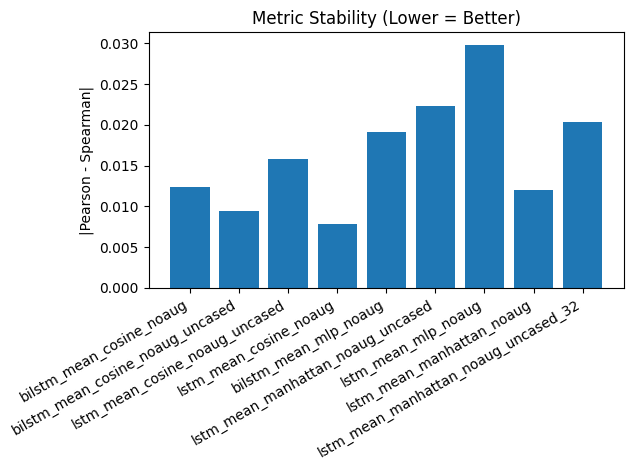

In [25]:
df["gap"] = abs(df["test_pearson"] - df["test_spearman"])

plt.figure()
plt.bar(df["name"], df["gap"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("|Pearson - Spearman|")
plt.title("Metric Stability (Lower = Better)")
plt.tight_layout()
plt.show()


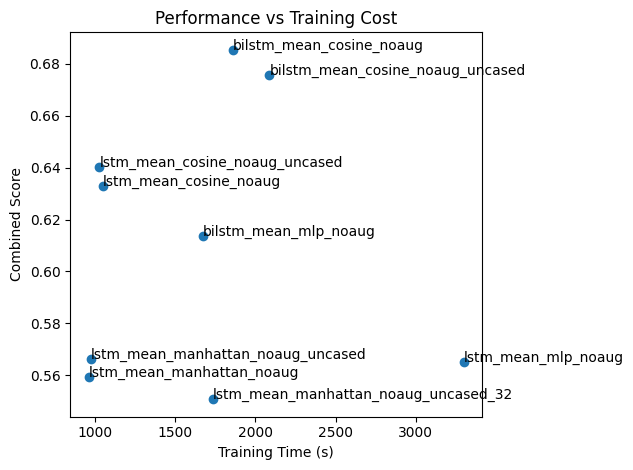

In [26]:
plt.figure()
plt.scatter(df["train_time_s"], df["combined"])

for i, txt in enumerate(df["name"]):
    plt.annotate(txt, (df["train_time_s"].iloc[i], df["combined"].iloc[i]))

plt.xlabel("Training Time (s)")
plt.ylabel("Combined Score")
plt.title("Performance vs Training Cost")
plt.tight_layout()
plt.show()


In [27]:
df["score"] = df["combined"] - df["test_mae"]

df_sorted = df.sort_values("score", ascending=False)

print(df_sorted[["name", "test_pearson", "test_spearman", "test_mae", "score"]])


                                   name  test_pearson  test_spearman  \
0              bilstm_mean_cosine_noaug      0.691568       0.679152   
1      bilstm_mean_cosine_noaug_uncased      0.680362       0.670979   
4        lstm_mean_cosine_noaug_uncased      0.648201       0.632440   
3                lstm_mean_cosine_noaug      0.636745       0.628953   
2                 bilstm_mean_mlp_noaug      0.623200       0.604026   
8                   lstm_mean_mlp_noaug      0.579978       0.550129   
5             lstm_mean_manhattan_noaug      0.565359       0.553311   
6     lstm_mean_manhattan_noaug_uncased      0.577505       0.555199   
7  lstm_mean_manhattan_noaug_uncased_32      0.560996       0.540593   

   test_mae     score  
0  0.192175  0.493185  
1  0.192147  0.483523  
4  0.203766  0.436554  
3  0.206806  0.426043  
2  0.189552  0.424061  
8  0.199168  0.365886  
5  0.205891  0.353444  
6  0.216535  0.349817  
7  0.216103  0.334691  


,name,n_win,avg_delta
8,lstm_mean_mlp_noaug,0,-0.011056
2,bilstm_mean_mlp_noaug,2,-0.005772
5,lstm_mean_manhattan_noaug,5,0.013750
7,lstm_mean_manhattan_noaug_uncased_32,5,0.024569
6,lstm_mean_manhattan_noaug_uncased,6,0.032060
1,bilstm_mean_cosine_noaug_uncased,6,0.034550
0,bilstm_mean_cosine_noaug,6,0.041479
4,lstm_mean_cosine_noaug_uncased,7,0.043526
3,lstm_mean_cosine_noaug,6,0.052179


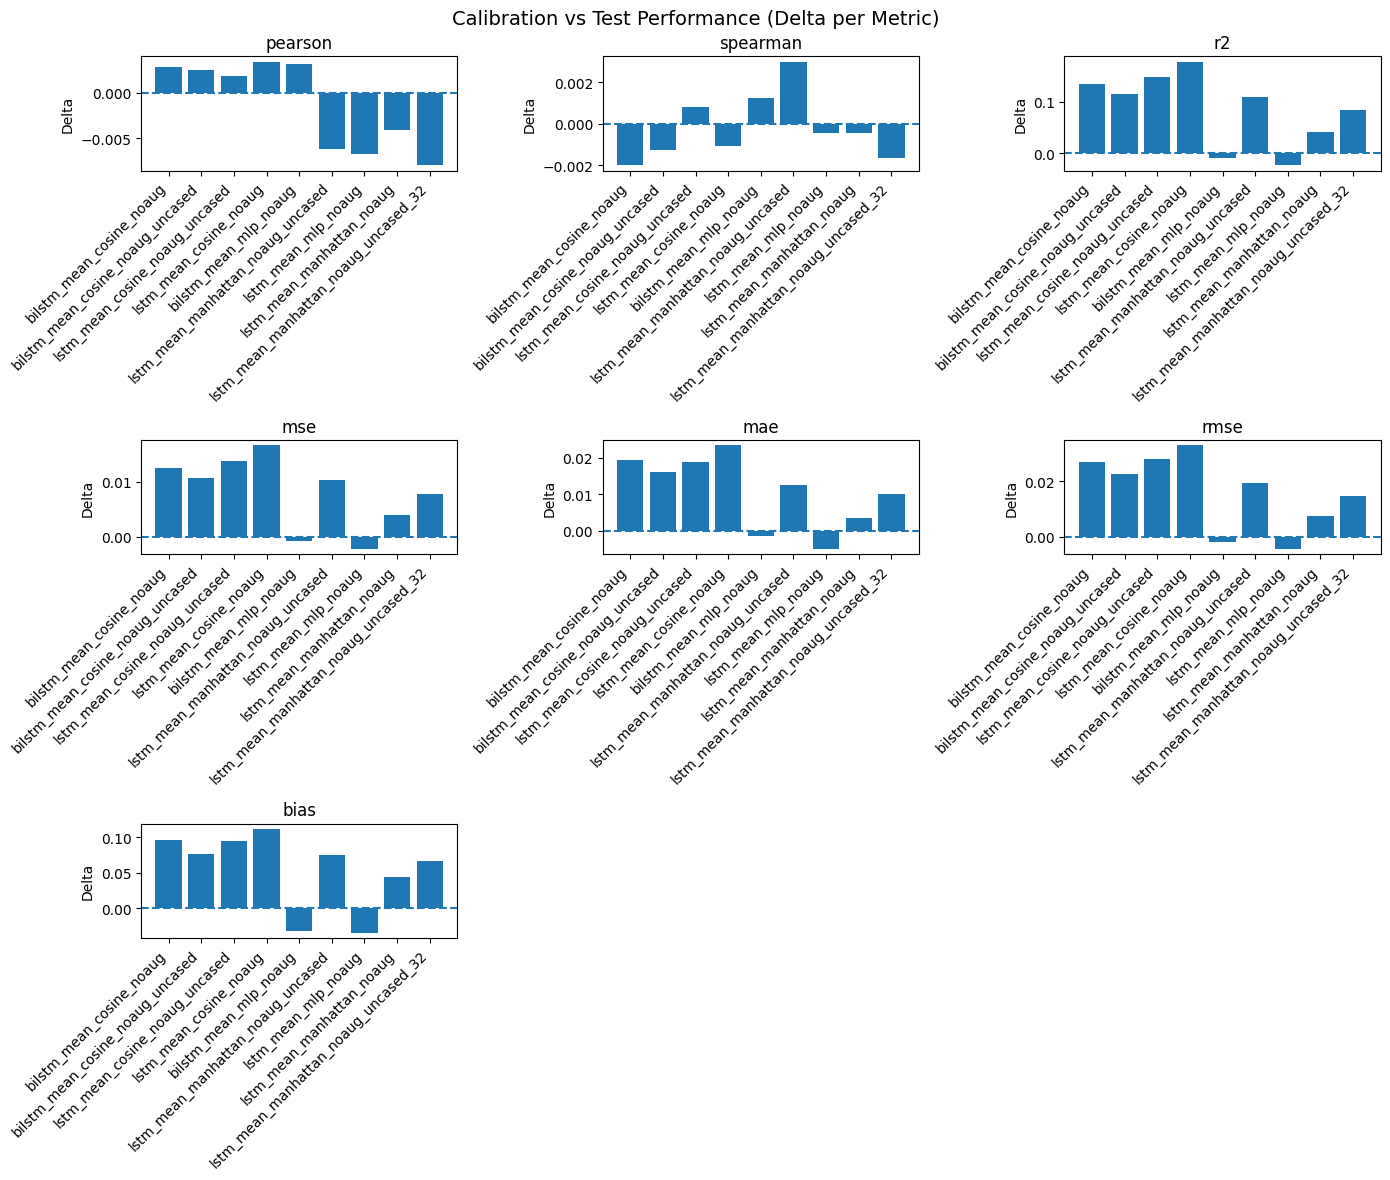

In [28]:
# Más alto --> mejor
pos_metrics = ["pearson", "spearman", "r2"]
# Más bajo --> mejor
neg_metrics = ["mse", "mae", "rmse"]
# Más cerca de 0 --> mejor
special_metrics = ["bias"]

# Cuando la diferencia es positiva, es mejor, de modo que usando calibración para el modelo, mejora ese parámetro.
for metric in pos_metrics:
	df[f"delta_{metric}"] = df[f"calibration_{metric}"] - df[f"test_{metric}"]

for metric in neg_metrics:
	df[f"delta_{metric}"] = df[f"test_{metric}"] - df[f"calibration_{metric}"]

for metric in special_metrics:
	df[f"delta_{metric}"] = abs(df[f"test_{metric}"]) - abs(df[f"calibration_{metric}"])
	
all_metrics = pos_metrics + neg_metrics + special_metrics

for metric in all_metrics:
	df[f"cal_win_{metric}"] = df[f"delta_{metric}"] > 0

df["n_win"] = df[[f"cal_win_{m}" for m in all_metrics]].sum(axis=1)
df["avg_delta"] = df[[f"delta_{m}" for m in all_metrics]].mean(axis=1)
df_ranked = df.sort_values("avg_delta")
display(df_ranked[["name", "n_win", "avg_delta"]])

n_metrics = len(all_metrics)
n_cols = 3
n_rows = math.ceil(n_metrics / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, metric in enumerate(all_metrics):
	ax = axes[i]

	ax.bar(df["name"], df[f"delta_{metric}"])
	
	ax.axhline(0, linestyle="--")

	ax.set_title(metric)
	ax.set_ylabel("Delta")

	ax.set_xticks(range(len(df)))
	ax.set_xticklabels(df["name"], rotation=45, ha="right")

for j in range(i + 1, len(axes)):
	fig.delaxes(axes[j])

fig.suptitle("Calibration vs Test Performance (Delta per Metric)", fontsize=14)
plt.tight_layout()
plt.show()
